# 🌀 Eigenvalues and Diagonalization — the Directions a Matrix Keeps

**Linear Algebra and Analytic Geometry** · TSIW, ESMAD — Polytechnic of Porto
Lesson notebook **06 of 08** · Library: [`linalg_utils`](../packages/python/src/linalg_utils)

> **Assignment alignment** — supplemental notebook (eigenvalues are not a graded
> assignment); closes the geometric arc begun in notebook 02.

---

Most vectors get knocked off their line when a matrix acts on them. A precious few do not:

$$A\mathbf{v} = \lambda\,\mathbf{v}, \qquad \mathbf{v} \neq \mathbf{0}.$$

Such an **eigenvector** $\mathbf{v}$ keeps its direction — the map merely *scales* it by the
**eigenvalue** $\lambda$. Along these special axes a matrix behaves like simple
multiplication, and expressing the map in that basis (**diagonalization**) makes hard
computations — like $A^{100}$ — trivial.

## Table of contents

1. [Setup](#setup)
2. [Spot the invariant directions](#invariant)
3. [Eigenpairs by hand: the 2×2 formula](#formula)
4. [Eigenvectors and the stretched circle](#circle)
5. [Power iteration: eigenvalues by repetition](#power)
6. [Diagonalization and fast matrix powers](#diagonalization)
7. [Application: a Markov chain reaching equilibrium](#markov)
8. [Key takeaways](#takeaways)

<a id="setup"></a>
## 1 · Setup

In [1]:
# ── Setup: imports, course library, and a consistent figure style ──────────
import sys
from pathlib import Path

# Make the course library importable straight from a repo clone
# (equivalent to `poetry install` inside packages/python).
_SRC = (Path.cwd().parent / "packages" / "python" / "src").resolve()
if _SRC.exists() and str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))

import numpy as np
import matplotlib.pyplot as plt

# Colorblind-safe categorical palette, used in fixed order across the series.
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
           "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
INK, MUTED, GRID, BASE = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor":   "#fcfcfb",
    "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor":   BASE,
    "axes.labelcolor":  INK,
    "axes.titlecolor":  INK,
    "axes.titleweight": "bold",
    "axes.grid":        True,
    "grid.color":       GRID,
    "grid.linewidth":   0.8,
    "xtick.color":      MUTED,
    "ytick.color":      MUTED,
    "axes.prop_cycle":  plt.cycler(color=PALETTE),
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "legend.frameon":   False,
    "figure.dpi":       110,
})
np.set_printoptions(precision=4, suppress=True)

import linalg_utils
print("NumPy", np.__version__, "| linalg_utils loaded from", Path(linalg_utils.__file__).parent)

NumPy 2.3.5 | linalg_utils loaded from C:\Users\diogo\work_code\linear-algebra-with-python\packages\python\src\linalg_utils


<a id="invariant"></a>
## 2 · Spot the invariant directions

Watch our running matrix
$A = \begin{pmatrix} 3 & 1 \\ 1 & 2 \end{pmatrix}$
act on a fan of unit vectors. Most output arrows (orange) point somewhere *new* relative to
their input (gray). But along two special directions, input and output line up perfectly —
those are the eigenvectors.

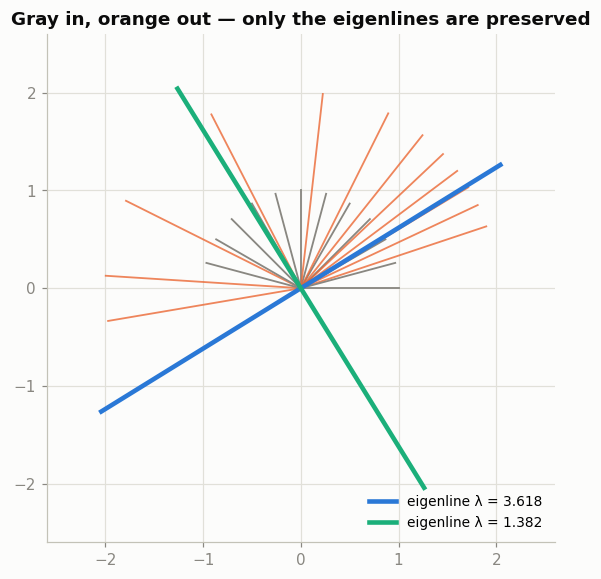

In [2]:
from linalg_utils.eigen import eigen_2x2

A = np.array([[3.0, 1.0], [1.0, 2.0]])
eig = eigen_2x2(A)

fig, ax = plt.subplots(figsize=(6.4, 6))
angles = np.linspace(0, np.pi, 12, endpoint=False)     # a fan of directions
for th in angles:
    v = np.array([np.cos(th), np.sin(th)])
    Av = A @ v
    Av_scaled = Av / np.linalg.norm(Av) * 2.0          # same length for comparability
    ax.plot([0, v[0]], [0, v[1]], color=MUTED, lw=1.2)
    ax.plot([0, Av_scaled[0]], [0, Av_scaled[1]], color=PALETTE[1], lw=1.2, alpha=0.8)
for k, colr in [(0, PALETTE[0]), (1, PALETTE[2])]:
    v = eig.eigenvectors[:, k]
    ax.plot([-2.4 * v[0], 2.4 * v[0]], [-2.4 * v[1], 2.4 * v[1]],
            color=colr, lw=3, label=f"eigenline λ = {eig.eigenvalues[k]:.3f}")
ax.set_xlim(-2.6, 2.6)
ax.set_ylim(-2.6, 2.6)
ax.set_aspect("equal")
ax.set_title("Gray in, orange out — only the eigenlines are preserved")
ax.legend(loc="lower right", fontsize=9)
plt.show()

<a id="formula"></a>
## 3 · Eigenpairs by hand: the 2×2 formula

Eigenvalues are the roots of the **characteristic polynomial**
$\det(A - \lambda I) = 0$. For a 2×2 matrix this is a quadratic with a closed form driven by
the trace and determinant:

$$\lambda^2 - \underbrace{(a+d)}_{\operatorname{tr} A}\lambda
  + \underbrace{(ad - bc)}_{\det A} = 0
\;\Longrightarrow\;
\lambda_{1,2} = \frac{\operatorname{tr} A \pm \sqrt{\operatorname{tr}^2 A - 4\det A}}{2}.$$

We verify the formula against the library, and confirm the defining equation
$A\mathbf{v} = \lambda\mathbf{v}$ numerically for both pairs.

In [3]:
tr, det = np.trace(A), np.linalg.det(A)
disc = np.sqrt(tr**2 - 4 * det)
lam_formula = np.array([(tr + disc) / 2, (tr - disc) / 2])
print(f"trace = {tr}, det = {det:.0f}")
print(f"by formula:       λ = {np.sort(lam_formula)[::-1]}")
print(f"by eigen_2x2:     λ = {np.sort(eig.eigenvalues)[::-1]}\n")

for k in range(2):
    lam, v = eig.eigenvalues[k], eig.eigenvectors[:, k]
    print(f"‖A·v{k+1} − λ{k+1}·v{k+1}‖ = {np.linalg.norm(A @ v - lam * v):.2e}   (≈ 0 ✔)")

# tr = sum of eigenvalues, det = product — two classic invariants:
print(f"\nλ₁ + λ₂ = {eig.eigenvalues.sum():.4f} = trace ✔")
print(f"λ₁ · λ₂ = {eig.eigenvalues.prod():.4f} = det ✔")

trace = 5.0, det = 5
by formula:       λ = [3.618 1.382]
by eigen_2x2:     λ = [3.618 1.382]

‖A·v1 − λ1·v1‖ = 2.22e-16   (≈ 0 ✔)
‖A·v2 − λ2·v2‖ = 2.48e-16   (≈ 0 ✔)

λ₁ + λ₂ = 5.0000 = trace ✔
λ₁ · λ₂ = 5.0000 = det ✔


<a id="circle"></a>
## 4 · Eigenvectors and the stretched circle

Because our $A$ is **symmetric**, its eigenvectors are orthogonal, and they line up exactly
with the axes of the ellipse $A\cdot(\text{unit circle})$ — for symmetric matrices,
eigenvalues *are* the singular values from notebook 05. Each eigenvector is drawn together
with its image $\lambda\mathbf{v}$: same direction, stretched by $\lambda$.

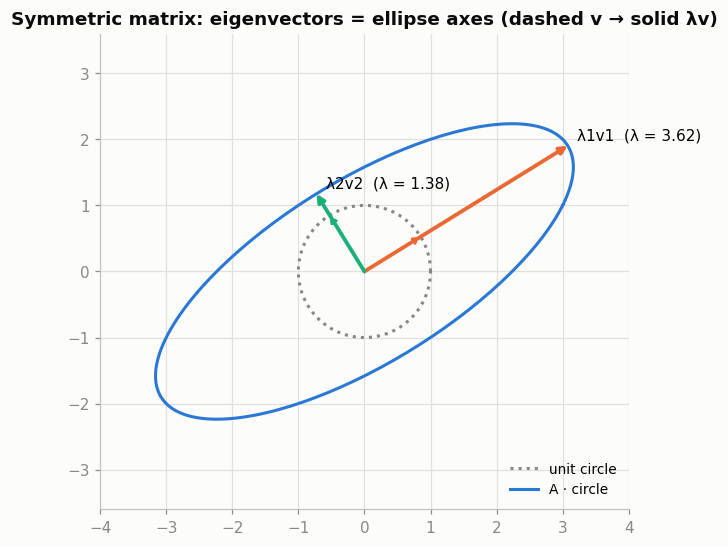

In [4]:
from linalg_utils.geometry2d import unit_circle, apply_linear_map

circle = unit_circle()
ellipse = apply_linear_map(A, circle)

fig, ax = plt.subplots(figsize=(6.2, 5.8))
ax.plot(circle[:, 0], circle[:, 1], color=MUTED, ls=":", lw=2, label="unit circle")
ax.plot(ellipse[:, 0], ellipse[:, 1], color=PALETTE[0], lw=2, label="A · circle")
for k, colr in [(0, PALETTE[1]), (1, PALETTE[2])]:
    lam, v = eig.eigenvalues[k], eig.eigenvectors[:, k]
    ax.annotate("", xy=tuple(lam * v), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color=colr, lw=2.5, shrinkA=0, shrinkB=0))
    ax.annotate("", xy=tuple(v), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color=colr, lw=1.4, ls="--",
                                shrinkA=0, shrinkB=0))
    ax.annotate(f"λ{k+1}v{k+1}  (λ = {lam:.2f})", xy=tuple(lam * v), xytext=(6, 4),
                textcoords="offset points", fontsize=10)
ax.set_xlim(-4.0, 4.0)
ax.set_ylim(-3.6, 3.6)
ax.set_aspect("equal")
ax.set_title("Symmetric matrix: eigenvectors = ellipse axes (dashed v → solid λv)")
ax.legend(loc="lower right", fontsize=9)
plt.show()

<a id="power"></a>
## 5 · Power iteration: eigenvalues by repetition

Repeatedly applying $A$ (and re-normalizing) makes *any* starting vector swing toward the
dominant eigenvector — the $\lambda_1$ component outgrows the rest exponentially fast, at
rate $|\lambda_2/\lambda_1|$ per step. The **Rayleigh quotient**

$$\rho(\mathbf{x}) = \frac{\mathbf{x}^{\mathsf T} A\, \mathbf{x}}{\mathbf{x}^{\mathsf T}\mathbf{x}}$$

converts each iterate into an eigenvalue estimate. This humble loop — the library's
`power_iteration` — is the ancestor of Google's PageRank and of large-scale sparse
eigensolvers.

power iteration : λ ≈ 5.0811388301  (16 iterations)
NumPy eig       : λ = 5.0811388301
Rayleigh quotient of returned vector: 5.0811388301


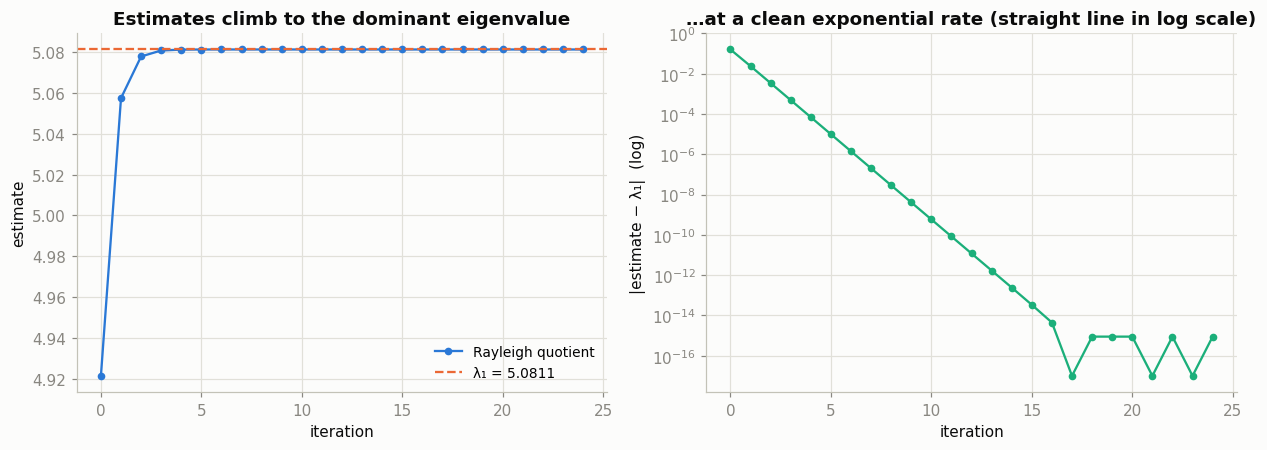

In [5]:
from linalg_utils.eigen import power_iteration, rayleigh_quotient

M = np.array([[4.0, 1.5], [1.5, 3.0]])
pi = power_iteration(M, tol=1e-12, seed=1)
lam_np = np.max(np.linalg.eigvals(M))

print(f"power iteration : λ ≈ {pi.eigenvalue:.10f}  ({pi.iterations} iterations)")
print(f"NumPy eig       : λ = {lam_np:.10f}")
print(f"Rayleigh quotient of returned vector: {rayleigh_quotient(M, pi.eigenvector):.10f}")

# Re-run the loop manually to record the convergence path.
rng = np.random.default_rng(1)
x = rng.normal(size=2)
x /= np.linalg.norm(x)
history = []
for _ in range(25):
    x = M @ x
    x /= np.linalg.norm(x)
    history.append(rayleigh_quotient(M, x))

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2))
ax[0].plot(history, marker="o", ms=4, color=PALETTE[0], label="Rayleigh quotient")
ax[0].axhline(lam_np, color=PALETTE[1], ls="--", label=f"λ₁ = {lam_np:.4f}")
ax[0].set_xlabel("iteration")
ax[0].set_ylabel("estimate")
ax[0].set_title("Estimates climb to the dominant eigenvalue")
ax[0].legend(fontsize=9)

err = np.abs(np.array(history) - lam_np)
ax[1].semilogy(np.maximum(err, 1e-17), marker="o", ms=4, color=PALETTE[2])
ax[1].set_xlabel("iteration")
ax[1].set_ylabel("|estimate − λ₁|  (log)")
ax[1].set_title("…at a clean exponential rate (straight line in log scale)")
plt.tight_layout()
plt.show()

<a id="diagonalization"></a>
## 6 · Diagonalization and fast matrix powers

Collect the eigenvectors as columns of $P$ and the eigenvalues in the diagonal $D$. If $P$ is
invertible,

$$A = P D P^{-1}
\qquad\Longrightarrow\qquad
A^{k} = P D^{k} P^{-1},$$

because every inner $P^{-1}P$ cancels. Powering a diagonal matrix means powering two scalars
— so $A^{100}$ costs no more than $A^2$. The map, *seen in its eigenbasis, is just two
independent stretches.*

In [6]:
P = eig.eigenvectors
D = np.diag(eig.eigenvalues)
P_inv = np.linalg.inv(P)

print("check A = P D P⁻¹:", np.allclose(A, P @ D @ P_inv), "\n")

k = 100
A100_diag = P @ np.diag(eig.eigenvalues ** k) @ P_inv   # instant
A100_loop = np.linalg.matrix_power(A, k)                # reference
print(f"‖A¹⁰⁰(diag) − A¹⁰⁰(loop)‖ / ‖A¹⁰⁰‖ = "
      f"{np.linalg.norm(A100_diag - A100_loop) / np.linalg.norm(A100_loop):.2e}")
print(f"largest entry of A¹⁰⁰ ≈ {A100_loop.max():.3e}"
      f"   (≈ λ₁¹⁰⁰ = {eig.eigenvalues.max() ** k:.3e} — the dominant eigenvalue rules)")

check A = P D P⁻¹: True 

‖A¹⁰⁰(diag) − A¹⁰⁰(loop)‖ / ‖A¹⁰⁰‖ = 1.48e-15
largest entry of A¹⁰⁰ ≈ 5.091e+55   (≈ λ₁¹⁰⁰ = 7.035e+55 — the dominant eigenvalue rules)


<a id="markov"></a>
## 7 · Application: a Markov chain reaching equilibrium

Diagonalization explains *long-run behavior*. Suppose students migrate weekly between three
study spots — **L**ibrary, **C**afé, **H**ome — with fixed transition probabilities. The
state evolves as $\mathbf{p}_{k+1} = T\mathbf{p}_k$, so $\mathbf{p}_k = T^k \mathbf{p}_0$.

A column-stochastic $T$ always has $\lambda_1 = 1$; its eigenvector is the **steady state**,
and every other component dies off like $\lambda_i^k$ — which is why the curves below
flatten geometrically fast, no matter where they start.

eigenvalues of T: [1.     0.5366 0.3634]
steady state    : {'Library': '37.3%', 'Café': '35.6%', 'Home': '27.1%'}


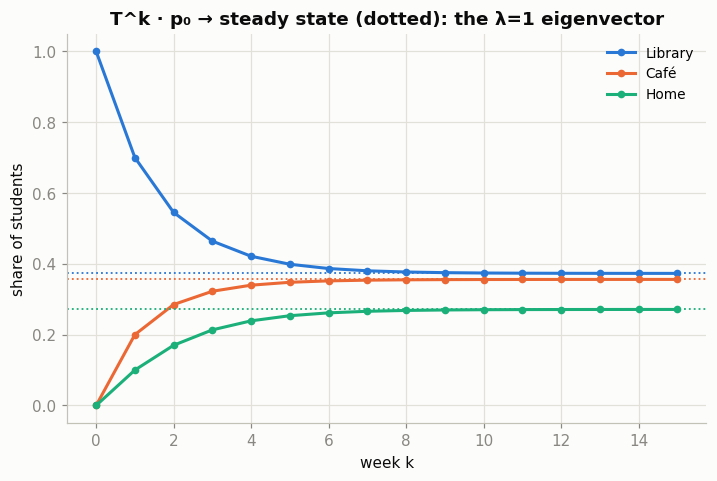

after 15 weeks: [0.3729 0.3559 0.2711]  vs  steady [0.3729 0.3559 0.2712]


In [7]:
# Columns = current spot, rows = next spot; each column sums to 1.
T = np.array([[0.70, 0.20, 0.15],    # → Library
              [0.20, 0.60, 0.25],    # → Café
              [0.10, 0.20, 0.60]])   # → Home
labels = ["Library", "Café", "Home"]

lam, V = np.linalg.eig(T)
print("eigenvalues of T:", np.round(lam.real, 4))
steady = V[:, np.argmax(lam.real)].real
steady /= steady.sum()               # normalize to probabilities
print("steady state    :", {l: f"{p:.1%}" for l, p in zip(labels, steady)})

p = np.array([1.0, 0.0, 0.0])        # everyone starts at the Library
weeks = 15
history = [p]
for _ in range(weeks):
    p = T @ p
    history.append(p)
history = np.array(history)

fig, ax = plt.subplots(figsize=(7.5, 4.6))
for j, (lab, colr) in enumerate(zip(labels, PALETTE)):
    ax.plot(history[:, j], marker="o", ms=4, lw=2, color=colr, label=lab)
    ax.axhline(steady[j], color=colr, ls=":", lw=1.2)
ax.set_xlabel("week k")
ax.set_ylabel("share of students")
ax.set_title("T^k · p₀ → steady state (dotted): the λ=1 eigenvector")
ax.legend(fontsize=9)
plt.show()

print(f"after {weeks} weeks: {np.round(history[-1], 4)}  vs  steady {np.round(steady, 4)}")

<a id="takeaways"></a>
## 8 · Key takeaways

- **Eigenvectors keep their direction**; eigenvalues are the scale factors:
  $A\mathbf{v} = \lambda\mathbf{v}$.
- For 2×2: $\lambda_{1,2}$ solve $\lambda^2 - \operatorname{tr}(A)\lambda + \det(A) = 0$;
  the trace is their **sum**, the determinant their **product**.
- **Symmetric matrices** have orthogonal eigenvectors that coincide with the axes of the
  image ellipse (their eigenvalues are the singular values of notebook 05).
- **Power iteration** finds the dominant pair by just multiplying — convergence rate
  $|\lambda_2/\lambda_1|$.
- **Diagonalization** $A = PDP^{-1}$ turns matrix powers into scalar powers, and predicts
  long-run dynamics: Markov chains converge to the $\lambda = 1$ eigenvector.

**Next:** [07 — PCA mini-project](07_pca_mini_project.ipynb): eigenvectors of a covariance
matrix become the axes along which *data* varies most.